In [ ]:
import os
from google.colab import drive

# 1. Mount Google Drive
drive.mount('/content/drive', force_remount=True)

PROJECT_DIR = '/content/drive/MyDrive/RetinaScreen'
DRIVE_DATA_DIR = f'{PROJECT_DIR}/datasets'

print("Copying ZIPs from Drive to fast local storage...")
# 2. Copy ZIPs directly from your shared Drive shortcut
!cp "{DRIVE_DATA_DIR}/aptos2019.zip" /content/
!cp "{DRIVE_DATA_DIR}/messidor2preprocess.zip" /content/
!cp "{DRIVE_DATA_DIR}/messidor2-dr-grades.zip" /content/

print("Unzipping APTOS 2019...")
!unzip -q -o /content/aptos2019.zip -d /content/aptos_data

print("Unzipping Messidor-2 Images & Labels...")
!unzip -q -o /content/messidor2preprocess.zip -d /content/messidor_data
!unzip -q -o /content/messidor2-dr-grades.zip -d /content/messidor_data

print("✅ All datasets loaded from Drive and unzipped! Ready for action.")

Mounted at /content/drive
Copying ZIPs from Drive to fast local storage...
Unzipping APTOS 2019...
Unzipping Messidor-2 Images & Labels...
✅ All datasets loaded from Drive and unzipped! Ready for action.


In [ ]:
import os

# Check what we actually have
print("=== APTOS ===")
!ls /content/aptos_data/
print("\n=== MESSIDOR ===")
!ls /content/messidor_data/

=== APTOS ===
test.csv  test_images  train_1.csv  train_images  valid.csv  val_images

=== MESSIDOR ===
messidor-2  messidor_data.csv  messidor_readme.txt


In [ ]:
!pip install -q timm==0.9.12 albumentations==1.3.1 grad-cam==1.4.8
!pip install -q coral-pytorch==1.4.0 scikit-learn torchmetrics netcal
!pip install -q plotly kaleido
print("All dependencies installed.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 122.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 102.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.7/125.7 kB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.0/236.0 kB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 30.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 59.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 5.8 

In [ ]:
import os, pandas as pd, numpy as np
import matplotlib.pyplot as plt, cv2
from glob import glob

# ── Auto-discover APTOS paths ──────────────────────────────────────────
APTOS_BASE = '/content/aptos_data'

# Find the CSV
aptos_csvs = glob(f'{APTOS_BASE}/**/*.csv', recursive=True)
print("APTOS CSVs found:", aptos_csvs)

# Find images folder
aptos_img_dirs = [d for d in glob(f'{APTOS_BASE}/**/', recursive=True)
                  if any(f.endswith('.png') for f in os.listdir(d))]
print("APTOS image dirs:", aptos_img_dirs)

# ── Auto-discover MESSIDOR paths ───────────────────────────────────────
MESS_BASE = '/content/messidor_data'
mess_csvs = glob(f'{MESS_BASE}/**/*.csv', recursive=True)
print("\nMessidor CSVs found:", mess_csvs)
mess_img_dirs = [d for d in glob(f'{MESS_BASE}/**/', recursive=True)
                 if any(f.endswith(('.jpg','.png','.jpeg'))
                        for f in os.listdir(d))]
print("Messidor image dirs:", mess_img_dirs)

APTOS CSVs found: ['/content/aptos_data/valid.csv', '/content/aptos_data/test.csv', '/content/aptos_data/train_1.csv']
APTOS image dirs: ['/content/aptos_data/val_images/val_images/', '/content/aptos_data/train_images/train_images/', '/content/aptos_data/test_images/test_images/']

Messidor CSVs found: ['/content/messidor_data/messidor_data.csv']
Messidor image dirs: ['/content/messidor_data/messidor-2/messidor-2/preprocess/']


APTOS total samples: 2930
diagnosis
0    1434
1     300
2     808
3     154
4     234
Name: count, dtype: int64


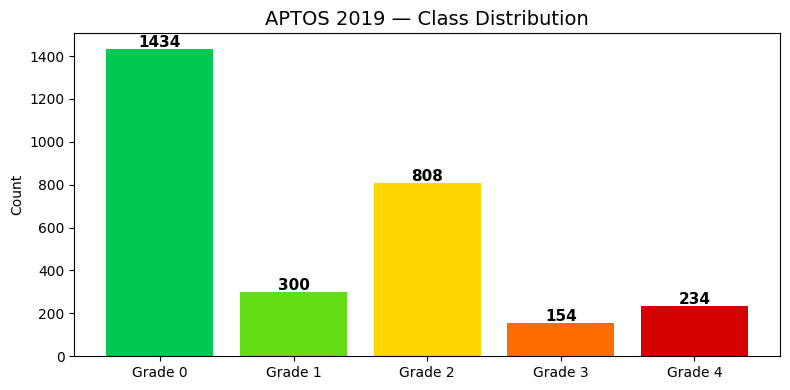

Severe class imbalance confirmed — WeightedSampler is critical.


In [ ]:
# ── SET THESE BASED ON CELL 3 OUTPUT ──────────────────────────────────
# Typical structure after the downloads you ran:
APTOS_CSV     = '/content/aptos_data/train_1.csv'          # adjust if needed
APTOS_IMG_DIR = '/content/aptos_data/train_images/train_images/'       # adjust if needed

MESS_LABEL_CSV = '/content/messidor_data/messidor_data.csv'  # adjust if needed
MESS_IMG_DIR   = '/content/messidor_data/IMAGES'             # adjust if needed

PROJECT_DIR = '/content/drive/MyDrive/RetinaScreen'

# ── Load and inspect ───────────────────────────────────────────────────
df = pd.read_csv(APTOS_CSV)
print(f"APTOS total samples: {len(df)}")
print(df['diagnosis'].value_counts().sort_index())

# Class distribution plot (no GPU needed)
fig, ax = plt.subplots(figsize=(8, 4))
counts = df['diagnosis'].value_counts().sort_index()
colors = ['#00C853','#64DD17','#FFD600','#FF6D00','#D50000']
bars = ax.bar([f'Grade {i}' for i in range(5)], counts.values, color=colors)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
            str(val), ha='center', fontsize=11, fontweight='bold')
ax.set_title('APTOS 2019 — Class Distribution', fontsize=14)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/class_dist.png', dpi=150)
plt.show()
print("Severe class imbalance confirmed — WeightedSampler is critical.")

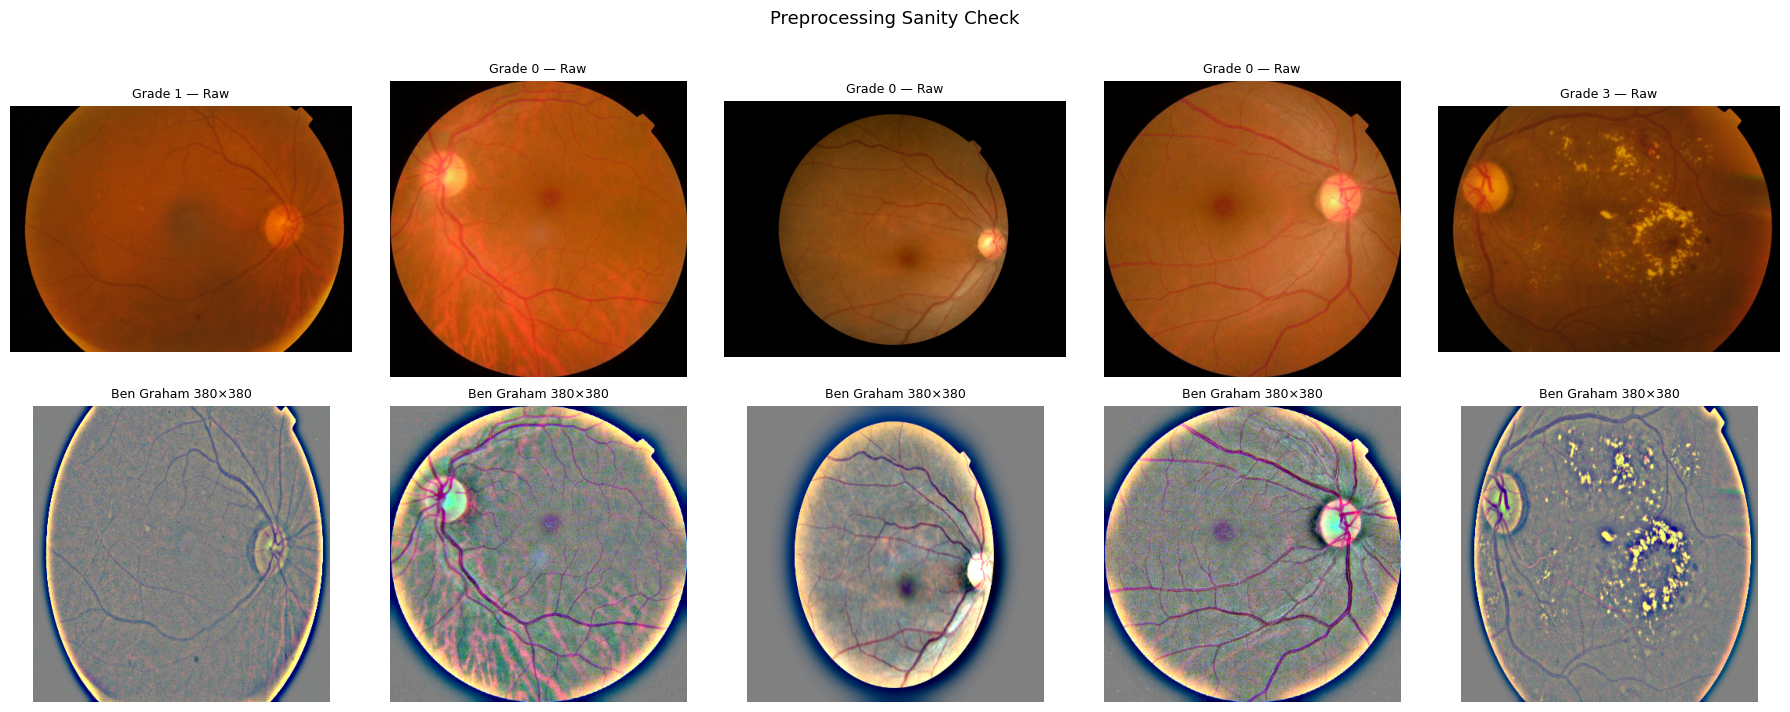

If vessels are visible and contrast is good — preprocessing is working.


In [ ]:
# Verify Ben Graham preprocessing visually before committing to it
import cv2, random
from PIL import Image
import matplotlib.pyplot as plt

sample_rows = df.sample(5, random_state=42)
fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, (_, row) in enumerate(sample_rows.iterrows()):
    img_path = f"{APTOS_IMG_DIR}/{row['id_code']}.png"
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Original
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Grade {row['diagnosis']} — Raw", fontsize=9)
    axes[0, i].axis('off')

    # Ben Graham preprocessed
    img_bg = cv2.addWeighted(img, 4, cv2.GaussianBlur(img, (0,0), 30), -4, 128)
    img_bg = cv2.resize(img_bg, (380, 380))
    axes[1, i].imshow(img_bg)
    axes[1, i].set_title("Ben Graham 380×380", fontsize=9)
    axes[1, i].axis('off')

plt.suptitle('Preprocessing Sanity Check', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/sample_preprocessing.png', dpi=120, bbox_inches='tight')
plt.show()
print("If vessels are visible and contrast is good — preprocessing is working.")

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import timm

# ── ACS-CORN Loss ──────────────────────────────────────────────────────
def acs_corn_loss(logits, targets, num_classes=5, beta_under=2.0, beta_over=1.0):
    """
    logits:  (batch, 4)   — CORN outputs, one per threshold
    targets: (batch,)     — integer grades 0-4
    """
    num_thresholds = num_classes - 1
    with torch.no_grad():
        pred_grades = (torch.sigmoid(logits) > 0.5).sum(dim=1).float()  # (batch,)

    total_loss = 0.0
    for k in range(num_thresholds):
        binary_target = (targets > k).float()                            # (batch,)
        bce = F.binary_cross_entropy_with_logits(
            logits[:, k], binary_target, reduction='none')               # (batch,)

        weights = torch.ones_like(bce)
        clinical_scale = (num_thresholds - k) / num_thresholds
        weights[pred_grades < targets.float()] = beta_under * (1 + clinical_scale)
        weights[pred_grades > targets.float()] = beta_over
        total_loss += (bce * weights).mean()

    return total_loss / num_thresholds


def get_grade_from_logits(logits):
    return (torch.sigmoid(logits) > 0.5).sum(dim=1)   # (batch,) int


# ── Dummy batch verification (run this ONCE before training) ───────────
def verify_acs_corn():
    dummy_logits  = torch.tensor([[2.0, 1.0, -1.0, -2.0],   # likely Grade 2
                                   [-2.0,-1.0,-1.0,-2.0]])   # likely Grade 0
    dummy_targets = torch.tensor([3, 0])  # under-grading case + correct
    loss = acs_corn_loss(dummy_logits, dummy_targets)
    assert not torch.isnan(loss), "LOSS IS NAN — STOP"
    assert loss.item() > 0, "LOSS IS ZERO — STOP"
    print(f"✅ ACS-CORN verified. Loss={loss.item():.4f} (should be > 0, not nan)")

    grades = get_grade_from_logits(dummy_logits)
    print(f"   Grade predictions: {grades.tolist()} (expected [2, 0])")

verify_acs_corn()


# ── Model ──────────────────────────────────────────────────────────────
class RetinaScreenModel(nn.Module):
    def __init__(self, num_classes=5, dropout_rate=0.4, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'efficientnet_b4', pretrained=pretrained,
            num_classes=0, global_pool='avg'
        )
        self.backbone.set_grad_checkpointing(True)   # saves ~30% VRAM
        self.dropout    = nn.Dropout(p=dropout_rate)
        self.classifier = nn.Linear(self.backbone.num_features, num_classes - 1)
        nn.init.xavier_normal_(self.classifier.weight)
        nn.init.zeros_(self.classifier.bias)

    def forward(self, x):
        # x:      (batch, 3, 380, 380)
        feat = self.backbone(x)    # (batch, 1792)
        feat = self.dropout(feat)  # (batch, 1792)  dropout active at train time
        return self.classifier(feat)  # (batch, 4)

print("✅ Model class defined.")

✅ ACS-CORN verified. Loss=0.8427 (should be > 0, not nan)
   Grade predictions: [2, 0] (expected [2, 0])
✅ Model class defined.


In [ ]:
# ============================================================
# CELL 7 (FIXED) — Dataset + DataLoaders (Fast Preprocessing)
# ============================================================
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
import torch
import cv2
import numpy as np
import pandas as pd

IMG_SIZE = 380

train_transform = A.Compose([
    A.CLAHE(clip_limit=2.0, tile_grid_size=(8,8), p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.Transpose(p=0.5),
    A.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05, p=0.5),
    A.CoarseDropout(max_holes=8, max_height=int(IMG_SIZE*0.08), max_width=int(IMG_SIZE*0.08), p=0.3),
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

val_transform = A.Compose([
    A.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ToTensorV2()
])

class APTOSDataset(Dataset):
    def __init__(self, df, img_dir, transform, id_col='id_code', label_col='diagnosis'):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform
        self.id_col    = id_col
        self.label_col = label_col

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = f"{self.img_dir}/{row[self.id_col]}.png"

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

        # THE FIX: Shrink the image FIRST before the heavy math
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

        # Now apply Ben Graham on the small, lightweight image
        img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img,(0,0),30), -4, 128)

        img = self.transform(image=img)['image']
        return img, int(row[self.label_col])

def build_loaders(csv_path, img_dir, batch_size=12, val_size=0.1, test_size=0.1):
    df = pd.read_csv(csv_path)
    train_df, test_df  = train_test_split(df, test_size=test_size, stratify=df['diagnosis'], random_state=42)
    train_df, val_df   = train_test_split(train_df, test_size=val_size/(1-test_size), stratify=train_df['diagnosis'], random_state=42)

    class_counts   = np.bincount(train_df['diagnosis'])
    sample_weights = (1.0 / class_counts)[train_df['diagnosis'].values]
    sampler        = WeightedRandomSampler(torch.FloatTensor(sample_weights), len(sample_weights), replacement=True)

    # Set num_workers=0 to prevent Colab multiprocessing deadlocks
    train_loader = DataLoader(APTOSDataset(train_df, img_dir, train_transform), batch_size=batch_size, sampler=sampler, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(APTOSDataset(val_df,   img_dir, val_transform), batch_size=batch_size*2, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(APTOSDataset(test_df,  img_dir, val_transform), batch_size=batch_size*2, shuffle=False, num_workers=0, pin_memory=True)

    return train_loader, val_loader, test_loader, test_df

train_loader, val_loader, test_loader, test_df = build_loaders(APTOS_CSV, APTOS_IMG_DIR)
print("✅ Fast Dataloaders Ready!")

✅ Fast Dataloaders Ready!


In [ ]:
# This cell will OOM-crash BEFORE your 25-epoch run does.
# If it passes, you are safe.
import torch
from torch.cuda.amp import autocast, GradScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"VRAM available: {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")

model = RetinaScreenModel(pretrained=True).to(device)
scaler = GradScaler()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

model.train()
for i, (imgs, lbls) in enumerate(train_loader):
    imgs, lbls = imgs.to(device), lbls.to(device)
    optimizer.zero_grad()
    with autocast():
        logits = model(imgs)           # (12, 4)
        loss   = acs_corn_loss(logits, lbls)
    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    mem = torch.cuda.memory_allocated()/1e9
    print(f"Step {i+1} | Loss: {loss.item():.4f} | VRAM used: {mem:.2f} GB")

    if i == 4:  # 5 steps is enough
        print("✅ VRAM smoke test passed. Safe to run full training.")
        break

del model  # free memory before real training
torch.cuda.empty_cache()

Device: cuda
VRAM available: 15.6 GB


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/77.9M [00:00<?, ?B/s]

/tmp/ipykernel_13031/531940374.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_13031/531940374.py:18: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step 1 | Loss: 1.3753 | VRAM used: 0.33 GB
Step 2 | Loss: 1.4960 | VRAM used: 0.33 GB
Step 3 | Loss: 1.2201 | VRAM used: 0.33 GB
Step 4 | Loss: 1.4804 | VRAM used: 0.33 GB
Step 5 | Loss: 1.1004 | VRAM used: 0.33 GB
✅ VRAM smoke test passed. Safe to run full training.


In [ ]:
# ============================================================
# CELL 9 (RESTORED) — Full Training Loop with Progress Bar & Resume
# ============================================================
import os
import json
import torch
from torch.cuda.amp import autocast, GradScaler
from sklearn.metrics import cohen_kappa_score
from tqdm.notebook import tqdm

def train_model(train_loader, val_loader, num_epochs=25, project_dir=PROJECT_DIR):
    device    = torch.device('cuda')
    model     = RetinaScreenModel(pretrained=True).to(device)

    optimizer = torch.optim.AdamW([
        {'params': model.backbone.parameters(), 'lr': 1e-5},
        {'params': model.classifier.parameters(), 'lr': 1e-3},
    ], weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=1, eta_min=1e-7)
    scaler         = GradScaler()
    GRAD_ACCUM     = 2
    PATIENCE       = 7
    best_qwk       = -1.0
    patience_count = 0
    history        = {'train_loss': [], 'val_qwk': [], 'val_loss': []}

    ckpt_path = f'{project_dir}/checkpoints/best_model.pth'
    start_epoch = 0

    # ---> THE RESTORED RESUME LOGIC <---

    if os.path.exists(ckpt_path):
        print(f"🔍 Found checkpoint at {ckpt_path}. Loading...")

        # THE FIX IS RIGHT HERE: Added weights_only=False
        ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)

        model.load_state_dict(ckpt['model_state_dict'])
        optimizer.load_state_dict(ckpt['optimizer_state_dict'])
        if 'scheduler_state_dict' in ckpt:
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
        best_qwk    = ckpt['best_qwk']
        start_epoch = ckpt['epoch'] + 1
        history     = ckpt.get('history', history)
        print(f"▶ SUCCESS! Resumed from epoch {start_epoch}, best QWK={best_qwk:.4f}")
    else:
        print("⚠️ No checkpoint found. Starting from scratch.")
    # -----------------------------------

    for epoch in range(start_epoch, num_epochs):
        print(f"\n--- Epoch {epoch+1}/{num_epochs} ---")

        # ── TRAIN ──────────────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        optimizer.zero_grad()

        for step, (imgs, lbls) in enumerate(tqdm(train_loader, desc="Training")):
            imgs, lbls = imgs.to(device, non_blocking=True), lbls.to(device)
            with autocast():
                logits = model(imgs)
                loss   = acs_corn_loss(logits, lbls) / GRAD_ACCUM
            scaler.scale(loss).backward()

            if (step + 1) % GRAD_ACCUM == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()

            train_loss += loss.item() * GRAD_ACCUM

        # ── VALIDATE ───────────────────────────────────────────────────
        model.eval()
        val_loss  = 0.0
        all_preds, all_lbls = [], []

        with torch.no_grad():
            for imgs, lbls in tqdm(val_loader, desc="Validating", leave=False):
                imgs, lbls = imgs.to(device), lbls.to(device)
                with autocast():
                    logits = model(imgs)
                    val_loss += acs_corn_loss(logits, lbls).item()
                all_preds.extend(get_grade_from_logits(logits).cpu().numpy())
                all_lbls.extend(lbls.cpu().numpy())

        qwk      = cohen_kappa_score(all_lbls, all_preds, weights='quadratic')
        avg_tloss = train_loss / len(train_loader)
        avg_vloss = val_loss   / len(val_loader)
        scheduler.step()

        history['train_loss'].append(avg_tloss)
        history['val_qwk'].append(qwk)
        history['val_loss'].append(avg_vloss)

        print(f"TLoss: {avg_tloss:.4f} | VLoss: {avg_vloss:.4f} | QWK: {qwk:.4f}")

        # Save latest
        torch.save({
            'epoch': epoch, 'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_qwk': best_qwk, 'history': history
        }, f'{project_dir}/checkpoints/latest_epoch.pth')

        # Save best
        if qwk > best_qwk:
            best_qwk = qwk
            patience_count = 0
            torch.save({
                'epoch': epoch, 'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_qwk': best_qwk, 'history': history
            }, ckpt_path)
            print(f"★ NEW BEST QWK: {best_qwk:.4f} (Saved to Drive)")
        else:
            patience_count += 1
            print(f"Patience: {patience_count}/{PATIENCE}")

        if patience_count >= PATIENCE:
            print(f"\nEarly stop at epoch {epoch+1}")
            break

    with open(f'{project_dir}/results/history.json', 'w') as f:
        json.dump(history, f)
    print(f"\nTraining complete. Best QWK: {best_qwk:.4f}")
    return model, history

model, history = train_model(train_loader, val_loader)

/tmp/ipykernel_2300/497153242.py:21: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler         = GradScaler()


🔍 Found checkpoint at /content/drive/MyDrive/RetinaScreen/checkpoints/best_model.pth. Loading...
▶ SUCCESS! Resumed from epoch 4, best QWK=0.8307

--- Epoch 5/25 ---


Training:   0%|          | 0/196 [00:00<?, ?it/s]

/tmp/ipykernel_2300/497153242.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Validating:   0%|          | 0/13 [00:00<?, ?it/s]

...

Training:   0%|          | 0/196 [00:00<?, ?it/s]

/tmp/ipykernel_2300/497153242.py:61: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Validating:   0%|          | 0/13 [00:00<?, ?it/s]

/tmp/ipykernel_2300/497153242.py:83: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


TLoss: 0.3790 | VLoss: 0.3187 | QWK: 0.8505
Patience: 5/7

Training complete. Best QWK: 0.8840


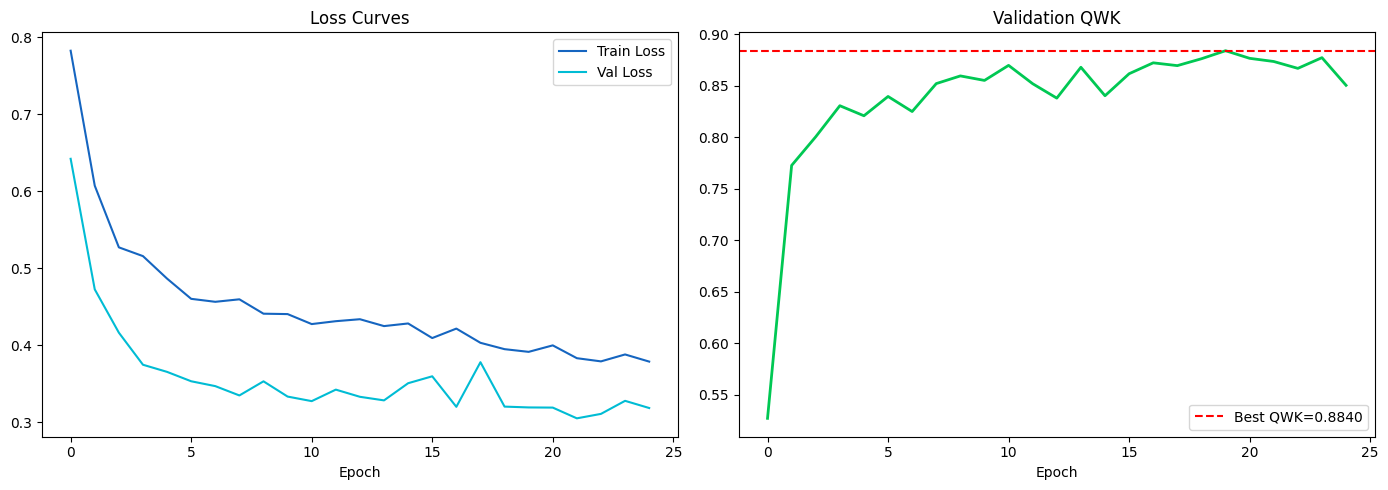

In [ ]:
import json, matplotlib.pyplot as plt

with open(f'{PROJECT_DIR}/results/history.json') as f:
    history = json.load(f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train Loss', color='#1565C0')
ax1.plot(history['val_loss'],   label='Val Loss',   color='#00BCD4')
ax1.set_title('Loss Curves'); ax1.legend(); ax1.set_xlabel('Epoch')

ax2.plot(history['val_qwk'], color='#00C853', linewidth=2)
ax2.axhline(max(history['val_qwk']), linestyle='--', color='red',
            label=f"Best QWK={max(history['val_qwk']):.4f}")
ax2.set_title('Validation QWK'); ax2.legend(); ax2.set_xlabel('Epoch')

plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/training_curves.png', dpi=150)
plt.show()

In [ ]:
import torch
import torch.nn as nn
import numpy as np

# Load best checkpoint
device = torch.device('cuda')
# FIX: Add weights_only=False to allow loading non-weight data from the checkpoint
ckpt   = torch.load(f'{PROJECT_DIR}/checkpoints/best_model.pth', map_location=device, weights_only=False)
model  = RetinaScreenModel(pretrained=False).to(device)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Loaded best model. Training QWK was: {ckpt['best_qwk']:.4f}")


def enable_mc_dropout(model):
    model.eval()
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()


def mc_predict_with_dud(model, img_tensor, n_passes=20, device='cuda'):
    enable_mc_dropout(model)
    if img_tensor.dim() == 3:
        img_tensor = img_tensor.unsqueeze(0)
    img_tensor = img_tensor.to(device)

    grades = []
    with torch.no_grad():
        for _ in range(n_passes):
            grades.append(get_grade_from_logits(model(img_tensor)).item())

    g          = np.array(grades, dtype=float)
    mean_g     = g.mean()
    final_g    = int(np.clip(round(mean_g), 0, 4))
    total_var  = g.var()

    upper = g[g > mean_g]; lower = g[g < mean_g]
    U_up   = ((upper - mean_g)**2).mean() if len(upper) > 0 else 0.0
    U_down = ((mean_g - lower)**2).mean() if len(lower) > 0 else 0.0

    eps = 1e-8
    CAS  = U_up / (U_up + U_down + eps)
    CRPS = float(np.clip((final_g/4)*0.4 + total_var*0.35 + CAS*0.25, 0, 1))

    return {'final_grade': final_g, 'mean_grade': round(mean_g,2),
            'total_variance': round(float(total_var),4),
            'U_up': round(float(U_up),4), 'U_down': round(float(U_down),4),
            'CAS': round(float(CAS),4), 'CRPS': round(CRPS,4),
            'all_grades': grades}


# ── Run DUD on full test set (this takes ~10 min) ──────────────────────
print("Running MC Dropout evaluation on test set...")
all_grades, all_labels = [], []
all_var, all_cas, all_crps = [], [], []
all_uup, all_udown = [], []

for imgs, lbls in test_loader:
    for i in range(len(imgs)):
        r = mc_predict_with_dud(model, imgs[i], n_passes=20, device='cuda')
        all_grades.append(r['final_grade'])
        all_labels.append(lbls[i].item())
        all_var.append(r['total_variance'])
        all_cas.append(r['CAS'])
        all_crps.append(r['CRPS'])
        all_uup.append(r['U_up'])
        all_udown.append(r['U_down'])

all_grades = np.array(all_grades)
all_labels = np.array(all_labels)

from sklearn.metrics import cohen_kappa_score
test_qwk = cohen_kappa_score(all_labels, all_grades, weights='quadratic')
print(f"\n✅ Test QWK: {test_qwk:.4f}")

# Save results so you don't have to rerun
np.save(f'{PROJECT_DIR}/results/test_results.npy', {
    'grades': all_grades, 'labels': all_labels,
    'var': all_var, 'cas': all_cas, 'crps': all_crps,
    'uup': all_uup, 'udown': all_udown
})

Loaded best model. Training QWK was: 0.8840
Running MC Dropout evaluation on test set...


/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)



✅ Test QWK: 0.8978


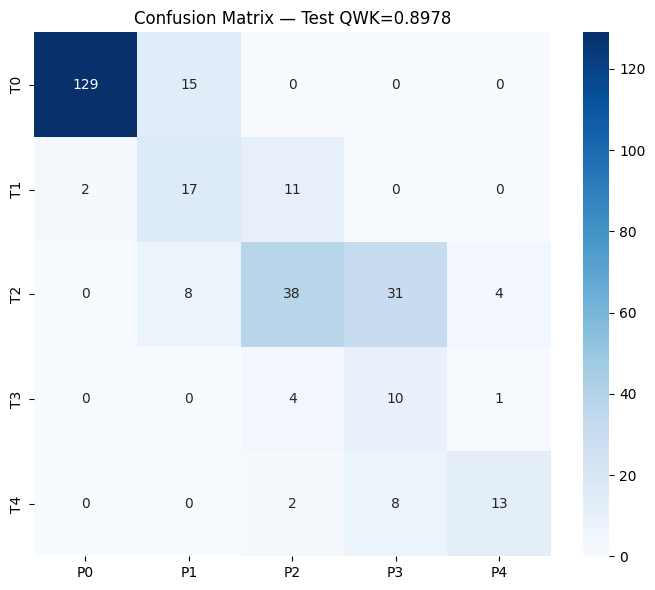

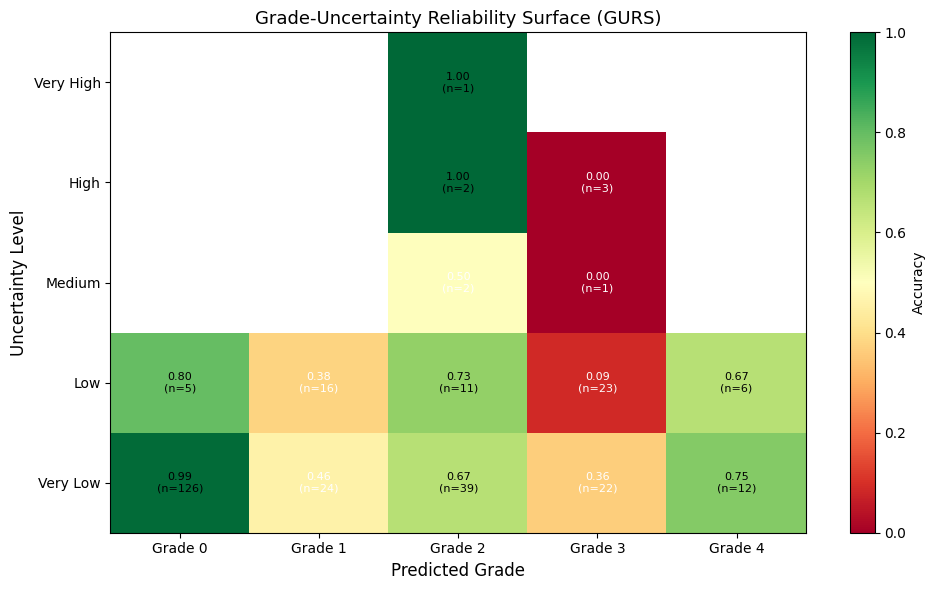

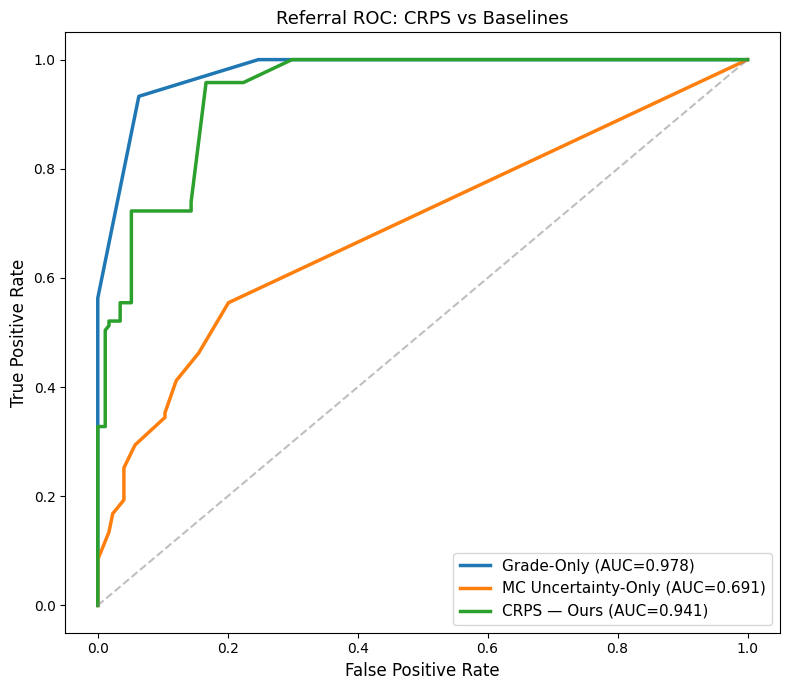

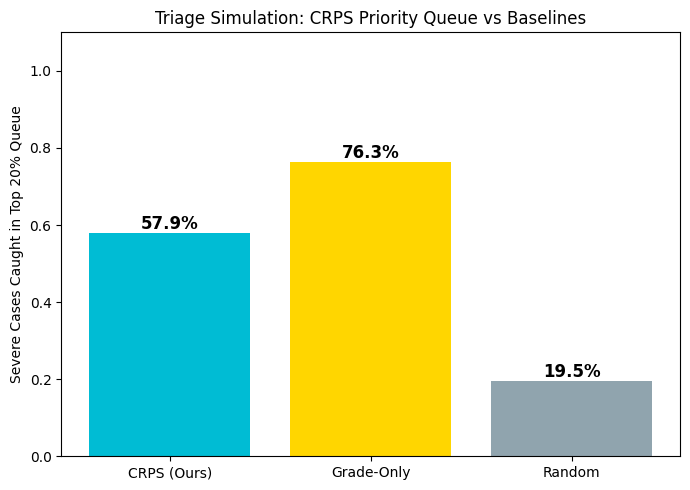


=== ALL EVALUATION FIGURES SAVED TO DRIVE ===
Triage simulation: {'CRPS (Ours)': np.float64(0.5789473684210527), 'Grade-Only': np.float64(0.7631578947368421), 'Random': np.float64(0.195)}


In [ ]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import seaborn as sns

# ── 1. Confusion Matrix ────────────────────────────────────────────────
cm = confusion_matrix(all_labels, all_grades)
fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'P{i}' for i in range(5)],
            yticklabels=[f'T{i}' for i in range(5)])
ax.set_title(f'Confusion Matrix — Test QWK={test_qwk:.4f}')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/confusion_matrix.png', dpi=150)
plt.show()

# ── 2. GURS (Grade-Uncertainty Reliability Surface) ────────────────────
n_bins = 5
unc_bins = np.linspace(0, max(all_var)+1e-6, n_bins+1)
surface  = np.full((5, n_bins), np.nan)
counts   = np.zeros((5, n_bins))

for pred, true, var in zip(all_grades, all_labels, all_var):
    b = int(np.clip(np.digitize(var, unc_bins)-1, 0, n_bins-1))
    if np.isnan(surface[pred, b]):
        surface[pred, b] = 0
    surface[pred, b] += int(pred == true)
    counts[pred, b]   += 1

with np.errstate(invalid='ignore'):
    surface = surface / counts

fig, ax = plt.subplots(figsize=(10,6))
im = ax.imshow(surface.T, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='lower')
ax.set_xticks(range(5)); ax.set_xticklabels([f'Grade {i}' for i in range(5)])
ax.set_yticks(range(n_bins))
ax.set_yticklabels(['Very Low','Low','Medium','High','Very High'])
ax.set_xlabel('Predicted Grade', fontsize=12)
ax.set_ylabel('Uncertainty Level', fontsize=12)
ax.set_title('Grade-Uncertainty Reliability Surface (GURS)', fontsize=13)
for i in range(5):
    for j in range(n_bins):
        if not np.isnan(surface[i,j]):
            ax.text(i, j, f'{surface[i,j]:.2f}\n(n={int(counts[i,j])})',
                    ha='center', va='center', fontsize=8,
                    color='black' if surface[i,j] > 0.5 else 'white')
plt.colorbar(im, label='Accuracy')
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/gurs.png', dpi=200, bbox_inches='tight')
plt.show()

# ── 3. Referral ROC Comparison ─────────────────────────────────────────
referral_gt  = (all_labels >= 2).astype(int)
grade_scores = all_grades / 4.0
unc_scores   = (np.array(all_var) - np.array(all_var).min()) / \
               (np.array(all_var).max() - np.array(all_var).min() + 1e-8)
crps_scores  = np.array(all_crps)

fig, ax = plt.subplots(figsize=(8,7))
for name, scores, color in [
    ('Grade-Only',          grade_scores, '#90A4AE'),
    ('MC Uncertainty-Only', unc_scores,   '#FFD600'),
    ('CRPS — Ours',         crps_scores,  '#00BCD4'),
]:
    fpr, tpr, _ = roc_curve(referral_gt, scores)
    ax.plot(fpr, tpr, label=f'{name} (AUC={auc(fpr,tpr):.3f})', linewidth=2.5)
ax.plot([0,1],[0,1],'--',color='gray',alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Referral ROC: CRPS vs Baselines', fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/referral_roc.png', dpi=150)
plt.show()

# ── 4. Triage Simulation ───────────────────────────────────────────────
severe      = (all_labels >= 3).astype(int)
total_sev   = severe.sum()
top_k       = int(len(all_labels) * 0.20)

sim_results = {
    'CRPS (Ours)': severe[np.argsort(-crps_scores)[:top_k]].sum() / total_sev,
    'Grade-Only':  severe[np.argsort(-all_grades)[:top_k]].sum()  / total_sev,
    'Random':      np.mean([severe[np.random.permutation(len(severe))[:top_k]].sum()
                            / total_sev for _ in range(100)])
}

fig, ax = plt.subplots(figsize=(7,5))
colors = ['#00BCD4','#FFD600','#90A4AE']
bars = ax.bar(sim_results.keys(), sim_results.values(), color=colors)
for bar, val in zip(bars, sim_results.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{val:.1%}', ha='center', fontsize=12, fontweight='bold')
ax.set_ylabel('Severe Cases Caught in Top 20% Queue')
ax.set_title('Triage Simulation: CRPS Priority Queue vs Baselines', fontsize=12)
ax.set_ylim(0, 1.1)
plt.tight_layout()
plt.savefig(f'{PROJECT_DIR}/results/triage_simulation.png', dpi=150)
plt.show()

print("\n=== ALL EVALUATION FIGURES SAVED TO DRIVE ===")
print(f"Triage simulation: {sim_results}")

In [ ]:
# Adjust these if Cell 3 showed different paths
MESS_LABEL_CSV = '/content/messidor_data/messidor_data.csv'
MESS_IMG_DIR   = '/content/messidor_data/IMAGES'

MESSIDOR_MAP = {0: 0, 1: 1, 2: 2, 3: 4}  # no Grade 3 in Messidor

df_mess = pd.read_csv(MESS_LABEL_CSV)
print(df_mess.columns.tolist())       # check column names
print(df_mess.head(3))

['image_id', 'adjudicated_dr_grade', 'adjudicated_dme', 'adjudicated_gradable']
                     image_id  adjudicated_dr_grade  adjudicated_dme  \
0  20051020_43808_0100_PP.png                   0.0              0.0   
1  20051020_43832_0100_PP.png                   1.0              0.0   
2  20051020_43882_0100_PP.png                   1.0              0.0   

   adjudicated_gradable  
0                     1  
1                     1  
2                     1  


In [ ]:
import os
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import cohen_kappa_score
import pandas as pd
from tqdm.notebook import tqdm

MESS_LABEL_CSV = '/content/messidor_data/messidor_data.csv'
MESS_IMG_DIR   = '/content/messidor_data/messidor-2/messidor-2/preprocess/' # FIX: Corrected image directory path

# FIX 3: Messidor-2 uses the standard 0-4 scale
MESS_ID_COL    = 'image_id'
MESS_LABEL_COL = 'adjudicated_dr_grade'

df_mess = pd.read_csv(MESS_LABEL_CSV)
df_mess = df_mess.dropna(subset=[MESS_LABEL_COL])
df_mess['diagnosis'] = df_mess[MESS_LABEL_COL].astype(int)

# Filter out rows where image files are missing
def check_image_exists(row, img_dir, id_col):
    img_name_with_ext = str(row[id_col])
    img_base_name = os.path.splitext(img_name_with_ext)[0]
    p_png = os.path.join(img_dir, img_base_name + '.png')
    p_jpg = os.path.join(img_dir, img_base_name + '.jpg')
    return os.path.exists(p_png) or os.path.exists(p_jpg)

initial_mess_count = len(df_mess)
df_mess = df_mess[df_mess.apply(lambda row: check_image_exists(row, MESS_IMG_DIR, MESS_ID_COL), axis=1)].reset_index(drop=True)
if len(df_mess) < initial_mess_count:
    print(f"Warning: Removed {initial_mess_count - len(df_mess)} entries from Messidor dataset due to missing image files.")

class MessidorDataset(Dataset):
    def __init__(self, df, img_dir, transform):
        self.df = df.reset_index(drop=True)
        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # FIX 1: The CSV already has the .png extension -> MODIFIED TO HANDLE MIXED EXTENSIONS
        img_name_with_ext = str(row[MESS_ID_COL])
        img_base_name = os.path.splitext(img_name_with_ext)[0]

        p_png = os.path.join(self.img_dir, img_base_name + '.png')
        p_jpg = os.path.join(self.img_dir, img_base_name + '.jpg')

        img_path = None
        if os.path.exists(p_png):
            img_path = p_png
        elif os.path.exists(p_jpg):
            img_path = p_jpg
        else:
            # This case should ideally not be hit after pre-filtering
            raise FileNotFoundError(f"Missing image: {img_base_name}.png or {img_base_name}.jpg in {self.img_dir}")

        img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)

        # FIX 2: Fast Resize to prevent CPU bottleneck!
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.addWeighted(img, 4, cv2.GaussianBlur(img,(0,0),30), -4, 128)

        img = self.transform(image=img)['image']
        return img, int(row['diagnosis'])

mess_loader = DataLoader(
    MessidorDataset(df_mess, MESS_IMG_DIR, val_transform),
    batch_size=24, shuffle=False, num_workers=0 # Safety against Colab deadlocks
)

# Run deterministic inference
model.eval()
mess_preds, mess_true = [], []

print("Running Cross-Dataset Evaluation on Messidor-2...")
with torch.no_grad():
    for imgs, lbls in tqdm(mess_loader, desc="Evaluating"):
        logits = model(imgs.to(device))
        mess_preds.extend(get_grade_from_logits(logits).cpu().numpy())
        mess_true.extend(lbls.numpy())

mess_qwk = cohen_kappa_score(mess_true, mess_preds, weights='quadratic')
print(f"\n✅ Cross-dataset QWK on Messidor-2: {mess_qwk:.4f}")
print(f"(APTOS test QWK was {test_qwk:.4f} — gap should be < 0.10 to claim generalization)")

Running Cross-Dataset Evaluation on Messidor-2...


Evaluating:   0%|          | 0/45 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)



✅ Cross-dataset QWK on Messidor-2: 0.4338
(APTOS test QWK was 0.8978 — gap should be < 0.10 to claim generalization)


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.amp import autocast, GradScaler
from sklearn.metrics import cohen_kappa_score, recall_score
import numpy as np
from tqdm.notebook import tqdm  # Added the progress bar!

# This uses GPU — runs after all evaluation is done
# Each config takes ~1.5 GPU hours — plan across 2 days if needed

def run_one_ablation_config(cfg_name, loss_type, train_loader, val_loader,
                            test_loader, project_dir, num_epochs=15):
    device    = torch.device('cuda')
    if loss_type == 'ce':
        m = RetinaScreenModel(pretrained=True)
        m.classifier = nn.Linear(m.backbone.num_features, 5)
    else:
        m = RetinaScreenModel(pretrained=True)
    m = m.to(device)

    opt = torch.optim.AdamW(m.parameters(), lr=1e-4, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=num_epochs)
    sc  = GradScaler('cuda')
    best_qwk = -1.0

    for epoch in range(num_epochs):
        m.train()

        # ---> PROGRESS BAR ADDED HERE <---
        for imgs, lbls in tqdm(train_loader, desc=f"[{cfg_name}] Train E{epoch+1}/{num_epochs}", leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)
            opt.zero_grad()
            with autocast('cuda'):
                out  = m(imgs)
                if loss_type == 'ce':
                    loss = F.cross_entropy(out, lbls)
                elif loss_type == 'corn':
                    from coral_pytorch.losses import corn_loss
                    loss = corn_loss(out, lbls, num_classes=5)
                else:
                    loss = acs_corn_loss(out, lbls)
            sc.scale(loss).backward(); sc.step(opt); sc.update()
        sch.step()

        m.eval()
        preds, trues = [], []
        with torch.no_grad():
            # ---> PROGRESS BAR ADDED HERE <---
            for imgs, lbls in tqdm(val_loader, desc="Validating", leave=False):
                out = m(imgs.to(device))
                p   = out.argmax(1) if loss_type=='ce' else get_grade_from_logits(out)
                preds.extend(p.cpu().numpy()); trues.extend(lbls.numpy())

        qwk = cohen_kappa_score(trues, preds, weights='quadratic')
        if qwk > best_qwk:
            best_qwk = qwk
            torch.save(m.state_dict(), f'{project_dir}/checkpoints/{cfg_name}.pth')
        print(f"  [{cfg_name}] E{epoch+1:02d} QWK={qwk:.4f}")

    # Test eval
    m.load_state_dict(torch.load(f'{project_dir}/checkpoints/{cfg_name}.pth', map_location=device, weights_only=False))
    m.eval()
    tp, tt = [], []
    with torch.no_grad():
        for imgs, lbls in test_loader:
            out = m(imgs.to(device))
            p   = out.argmax(1) if loss_type=='ce' else get_grade_from_logits(out)
            tp.extend(p.cpu().numpy()); tt.extend(lbls.numpy())

    tp, tt  = np.array(tp), np.array(tt)
    test_q  = cohen_kappa_score(tt, tp, weights='quadratic')
    mask34  = tt >= 3
    rec34   = recall_score(tt[mask34]>=3, tp[mask34]>=3, zero_division=0) if mask34.sum()>0 else 0
    print(f"\n★ Final {cfg_name}: QWK={test_q:.4f} | Grade3+4 Recall={rec34:.4f}\n")
    return {'QWK': round(test_q,4), 'Recall_3_4': round(rec34,4)}

ablation_results = {}
for cfg_name, loss_type in [('CE_Baseline','ce'),
                              ('CORN_Ordinal','corn'),
                              ('ACS_CORN_Ours','acs_corn')]:
    print(f"\n>>> Starting {cfg_name}...")
    ablation_results[cfg_name] = run_one_ablation_config(
        cfg_name, loss_type, train_loader, val_loader, test_loader, PROJECT_DIR)

print("\n====== ABLATION TABLE ======")
print(f"{'Config':<20} | {'QWK':>6} | {'Recall 3+4':>10}")
print("-" * 42)
for name, res in ablation_results.items():
    print(f"{name:<20} | {res['QWK']:>6.4f} | {res['Recall_3_4']:>10.4f}")


>>> Starting CE_Baseline...


[CE_Baseline] Train E1/15:   0%|          | 0/196 [00:00<?, ?it/s]

Validating:   0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


  [CE_Baseline] E01 QWK=0.8335


...

Validating:   0%|          | 0/13 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/checkpoint.py:232: UserWarning: None of the inputs have requires_grad=True. Gradients will be None
  check_backward_validity(args)


  [CORN_Ordinal] E06 QWK=0.7177


[CORN_Ordinal] Train E7/15:   0%|          | 0/196 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
